<a href="https://colab.research.google.com/github/Gaurav9571/week1_Gaurav_Mittal/blob/main/WEEK4_GAURAV_MITTAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

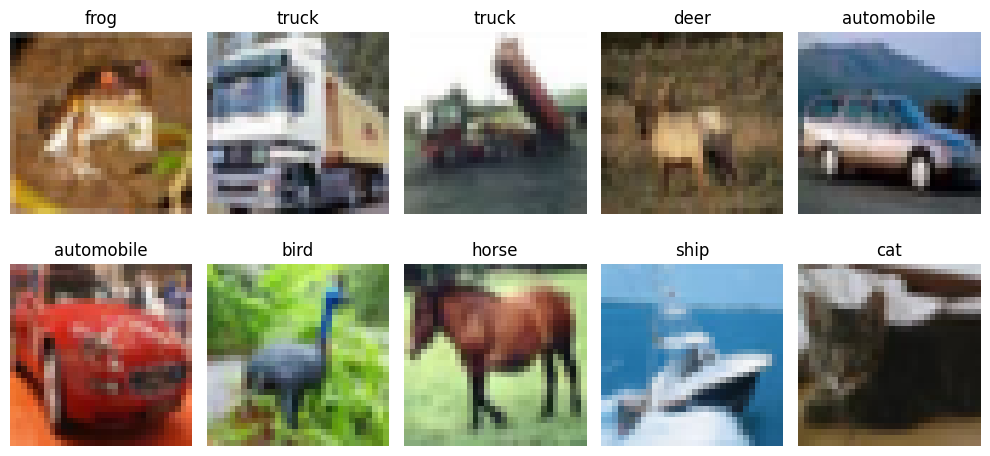

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.2670 - loss: 1.9994 - val_accuracy: 0.3272 - val_loss: 1.8662
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - accuracy: 0.3051 - loss: 1.8900 - val_accuracy: 0.3518 - val_loss: 1.8060
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3285 - loss: 1.8305 - val_accuracy: 0.3622 - val_loss: 1.7813
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3440 - loss: 1.7982 - val_accuracy: 0.3836 - val_loss: 1.7456
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3555 - loss: 1.7695 - val_accuracy: 0.3950 - val_loss: 1.7407
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3635 - loss: 1.7505 - val_accuracy: 0.3890 - val_loss: 1.7144
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3732 - loss: 1.7306 - val_accuracy: 0.3970 - val_loss: 1.7242
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3796 - loss: 1.7124 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4287 - loss: 1.6380
ANN Test Accuracy: 0.4287000000476837


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 123ms/step - accuracy: 0.4663 - loss: 1.4805 - val_accuracy: 0.4294 - val_loss: 1.8336
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.6076 - loss: 1.1257 - val_accuracy: 0.6164 - val_loss: 1.0927
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 121ms/step - accuracy: 0.6610 - loss: 0.9645 - val_accuracy: 0.6440 - val_loss: 1.0020
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 122ms/step - accuracy: 0.7021 - loss: 0.8529 - val_accuracy: 0.6624 - val_loss: 0.9650
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.7342 - loss: 0.7594 - val_accuracy: 0.6316 - val_loss: 1.1660
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 119ms/step - accuracy: 0.7626 - loss: 0.6781 - val_accuracy: 0.7194 - val_loss: 0.8307
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 119ms/step - accuracy: 0.7817 - loss: 0.6159 - val_accuracy: 0.6062 - val_loss: 1.3230
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.8025 - los

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6778 - loss: 1.0917
CNN Test Accuracy: 0.6777999997138977


## 📈 Compare Learning Curves

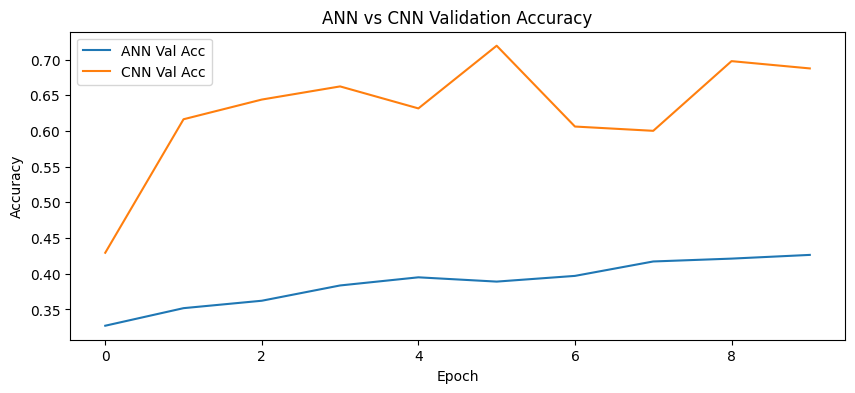

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4287
1,CNN,0.6778


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

improved_ann = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

improved_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_ann_history = improved_ann.fit(
    x_train_flat,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.2542 - loss: 2.0145 - val_accuracy: 0.3172 - val_loss: 1.8763
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3153 - loss: 1.8679 - val_accuracy: 0.3474 - val_loss: 1.8066
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3307 - loss: 1.8216 - val_accuracy: 0.3496 - val_loss: 1.7919
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.3496 - loss: 1.7825 - val_accuracy: 0.3938 - val_loss: 1.7359
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3598 - loss: 1.7545 - val_accuracy: 0.3976 - val_loss: 1.7071
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 63ms/step - accuracy: 0.3665 - loss: 1.7391 - val_accuracy: 0.4002 - val_loss: 1.6764
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 66ms/step - accuracy: 0.3693 - loss: 1.7297 - val_accuracy: 0.4084 - val_loss: 1.6739
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3717 - loss: 1.7210 - 

In [ ]:
improved_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

improved_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_cnn_history = improved_cnn.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 123ms/step - accuracy: 0.4792 - loss: 1.4783 - val_accuracy: 0.5658 - val_loss: 1.2299
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.6135 - loss: 1.0904 - val_accuracy: 0.6014 - val_loss: 1.1371
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 123ms/step - accuracy: 0.6737 - loss: 0.9307 - val_accuracy: 0.6234 - val_loss: 1.1019
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.7103 - loss: 0.8234 - val_accuracy: 0.6072 - val_loss: 1.1564
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.7436 - loss: 0.7295 - val_accuracy: 0.6854 - val_loss: 0.9256
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.7702 - loss: 0.6590 - val_accuracy: 0.6600 - val_loss: 1.0731
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.7894 - loss: 0.5977 - val_accuracy: 0.7212 - val_loss: 0.8463
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 120ms/step - accuracy: 0.8082 - loss: 

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

improved_ann_acc = improved_ann.evaluate(x_test_flat, y_test, verbose=0)[1]
improved_cnn_acc = improved_cnn.evaluate(x_test_norm, y_test, verbose=0)[1]
aug_cnn_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)[1]

results = pd.DataFrame({
    'Model':['Improved ANN','Improved CNN','Augmented CNN'],
    'Test Accuracy':[improved_ann_acc, improved_cnn_acc, aug_cnn_acc]
})

print(results)
results


Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 71s 49ms/step - accuracy: 0.3784 - loss: 1.7051 - val_accuracy: 0.4970 - val_loss: 1.3832
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.4803 - loss: 1.4516 - val_accuracy: 0.5304 - val_loss: 1.2925
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.5161 - loss: 1.3609 - val_accuracy: 0.5776 - val_loss: 1.1861
           Model  Test Accuracy
0   Improved ANN         0.4488
1   Improved CNN         0.7094
2  Augmented CNN         0.4913


,Model,Test Accuracy
0,Improved ANN,0.4488
1,Improved CNN,0.7094
2,Augmented CNN,0.4913


# Conclusion

Based on the analysis, the Improved CNN model achieved the highest test accuracy of 0.7094, significantly outperforming both the Improved ANN (0.4488) and the Augmented CNN (0.4913). This demonstrates the effectiveness of convolutional layers in capturing spatial features crucial for image classification tasks, especially when combined with techniques like Batch Normalization and Dropout for regularization. The use of EarlyStopping helped prevent overfitting and ensured that the models retained their best performance on unseen data.

## Business Conclusion

For a business application requiring high accuracy in image classification, such as product categorization for e-commerce, quality control in manufacturing, or object recognition in autonomous systems, the **Improved CNN model** is the clear recommendation. Its superior performance in terms of test accuracy (70.94%) indicates a robust ability to correctly identify and classify images, which translates directly to reduced errors, improved automation, and better decision-making. While data augmentation showed some benefits, the current implementation of the Improved CNN without explicit augmentation in the final training run already yields a strong result. Further investment should focus on optimizing and deploying this CNN architecture, potentially exploring more sophisticated augmentation strategies or transfer learning with pre-trained models to push accuracy even higher, which could lead to significant operational efficiencies and cost savings.